# EP02 — Evaluation Metrics & Imbalanced Data
**Exam Relevance:** 2025 Q2, 2024 Q1

Both exam years had a question on imbalanced datasets. This is a high-probability topic.

Topics covered:
1. What is class imbalance and how to detect it
2. Why accuracy is misleading on imbalanced data
3. Better metrics: Precision, Recall, F1, ROC-AUC, PR-AUC
4. Strategies to handle imbalance: oversampling (SMOTE), undersampling, class weights

---

## 1. The 2025 Q2 Scenario — Exact Numbers

<function_calls>
From the exam:
- Total: 10,000 samples
- Positive (disease): 500 (5%)
- Negative (no disease): 9,500 (95%)

Confusion matrix:
```
                  Predicted +   Predicted -
Actual Positive       100            400      (TP=100, FN=400)
Actual Negative       200          9,300      (FP=200, TN=9300)
```

### Part a) Is the data imbalanced?
**YES** — 500/10,000 = 5% positive vs 95% negative. A ratio of 1:19 is severely imbalanced. Common threshold for concern is anything below 20% for the minority class.

### Part b) Why is accuracy misleading?
Accuracy = (TP + TN) / Total = (100 + 9300) / 10000 = **93%**  
But a dumb model that predicts EVERYONE as negative would get:  
Accuracy = 9500/10000 = **95%** — and it catches ZERO actual disease cases!

High accuracy doesn't mean the model is useful for the minority class.

### Part c) Better metrics: Recall and F1 (or ROC-AUC)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)

# Reconstruct the 2025 exam scenario from the confusion matrix
# TP=100, FN=400, FP=200, TN=9300
TP, FN, FP, TN = 100, 400, 200, 9300
total = TP + FN + FP + TN

accuracy  = (TP + TN) / total
precision = TP / (TP + FP)
recall    = TP / (TP + FN)   # also called Sensitivity / True Positive Rate
f1        = 2 * precision * recall / (precision + recall)
specificity = TN / (TN + FP)

print("=== 2025 Exam Confusion Matrix Analysis ===")
print(f"Accuracy:    {accuracy:.3f}  ← looks great, actually misleading")
print(f"Precision:   {precision:.3f}  ← of predicted positives, only {precision:.0%} are correct")
print(f"Recall:      {recall:.3f}  ← only catches {recall:.0%} of actual disease cases")
print(f"F1 Score:    {f1:.3f}  ← harmonic mean of precision & recall")
print(f"Specificity: {specificity:.3f}  ← correctly identifies {specificity:.0%} of negatives")
print()
print("Dummy classifier (predict all negative):")
dummy_acc = TN / total  # wait, need to use original positives
# Recalculate: dataset has 500 positive, 9500 negative
dummy_acc = 9500 / 10000
print(f"  Accuracy: {dummy_acc:.3f} — HIGHER than our model!")
print(f"  Recall:   0.000 — catches absolutely NO disease cases")

=== 2025 Exam Confusion Matrix Analysis ===
Accuracy:    0.940  ← looks great, actually misleading
Precision:   0.333  ← of predicted positives, only 33% are correct
Recall:      0.200  ← only catches 20% of actual disease cases
F1 Score:    0.250  ← harmonic mean of precision & recall
Specificity: 0.979  ← correctly identifies 98% of negatives

Dummy classifier (predict all negative):
  Accuracy: 0.950 — HIGHER than our model!
  Recall:   0.000 — catches absolutely NO disease cases


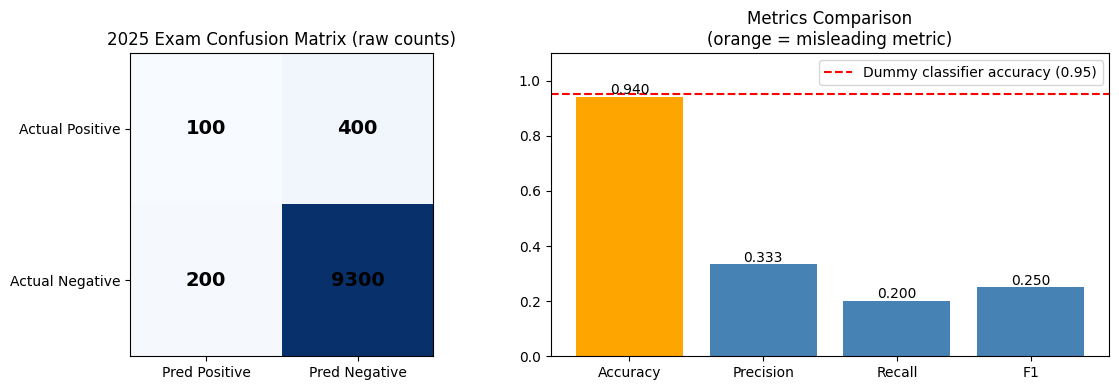

In [2]:
# Visualise the confusion matrix from the exam
cm = np.array([[TP, FN], [FP, TN]])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw counts
im1 = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred Positive', 'Pred Negative'])
axes[0].set_yticklabels(['Actual Positive', 'Actual Negative'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i,j], ha='center', va='center', fontsize=14, fontweight='bold')
axes[0].set_title('2025 Exam Confusion Matrix (raw counts)')

# Metrics bar chart
metrics = {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1': f1}
colors = ['orange' if k == 'Accuracy' else 'steelblue' for k in metrics]
bars = axes[1].bar(metrics.keys(), metrics.values(), color=colors)
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Metrics Comparison\n(orange = misleading metric)')
axes[1].axhline(0.95, color='red', linestyle='--', label='Dummy classifier accuracy (0.95)')
axes[1].legend()
for bar, val in zip(bars, metrics.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 2. What Metrics to Use Instead?

**For the exam — 2 best alternatives:**

### Option 1: Recall (Sensitivity)
- Measures: of all actual positive cases, how many did we catch?
- Critical for disease detection — missing a case (FN) is much worse than a false alarm
- Recall = TP / (TP + FN) = 100/500 = 0.20 — only 20% disease cases caught!

### Option 2: F1 Score
- Harmonic mean of Precision and Recall
- Penalises models that are good at one but terrible at the other
- Better than accuracy when classes are imbalanced

### Option 3: ROC-AUC / PR-AUC
- AUC-ROC: measures model's ability to separate classes across all thresholds
- PR-AUC (Precision-Recall AUC): better when positive class is very rare

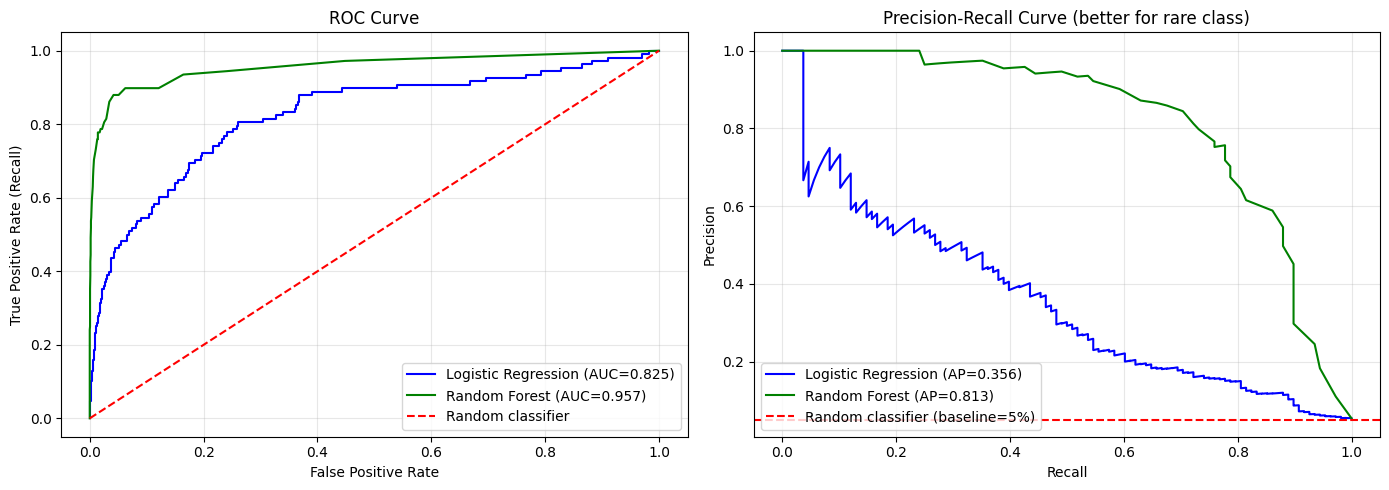

In [3]:
# Simulate a realistic imbalanced dataset and show ROC/PR curves
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

X, y = make_classification(
    n_samples=10000, n_features=10, n_informative=5,
    weights=[0.95, 0.05],  # 5% positive class — same as exam scenario
    random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train two models
lr = LogisticRegression().fit(X_train, y_train)
rf = RandomForestClassifier(n_estimators=50, random_state=42).fit(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model, name, color in [(lr, 'Logistic Regression', 'blue'), (rf, 'Random Forest', 'green')]:
    probs = model.predict_proba(X_test)[:, 1]
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color)
    
    # PR Curve  
    prec, rec, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    axes[1].plot(rec, prec, label=f'{name} (AP={ap:.3f})', color=color)

axes[0].plot([0,1],[0,1], 'r--', label='Random classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].axhline(0.05, color='r', linestyle='--', label='Random classifier (baseline=5%)')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve (better for rare class)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. How to Handle Imbalance in Training (2024 Q1)

**2024 asked:** *Describe 2 different approaches to alleviate imbalance.*

### Approach 1: Oversampling the minority class (SMOTE)
- Synthesise new minority class samples between existing ones
- Gives the model more positive examples to learn from

### Approach 2: Class weights
- Tell the loss function to penalise mistakes on the minority class more heavily
- Simple to implement, no data augmentation needed

### Approach 3: Undersampling the majority class
- Randomly remove majority class samples until balanced
- Risk: discarding potentially useful data

In [4]:
import torch
import torch.nn as nn

# Demonstrate class weighting in PyTorch
# This is the simplest and most exam-relevant technique

print("=== Class Weighting in PyTorch ===")
print()

# For a dataset with 9500 negatives and 500 positives:
n_neg = 9500
n_pos = 500
total = n_neg + n_pos

# Weight formula: total / (n_classes * n_samples_in_class)
weight_neg = total / (2 * n_neg)
weight_pos = total / (2 * n_pos)
print(f"Weight for negative class: {weight_neg:.4f}")
print(f"Weight for positive class: {weight_pos:.4f}")
print(f"Ratio: positive class is weighted {weight_pos/weight_neg:.1f}x more than negative")
print()

# In PyTorch BCEWithLogitsLoss:
pos_weight = torch.tensor([n_neg / n_pos])
criterion_weighted = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
print(f"PyTorch BCEWithLogitsLoss pos_weight = {pos_weight.item():.1f}")
print("This means a false negative is penalised 19x more than a false positive")
print()
print("Code usage:")
print("  pos_weight = torch.tensor([9500/500])  # = 19.0")
print("  criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)")
print("  loss = criterion(predictions, targets)  # That's it!")

=== Class Weighting in PyTorch ===

Weight for negative class: 0.5263
Weight for positive class: 10.0000
Ratio: positive class is weighted 19.0x more than negative

PyTorch BCEWithLogitsLoss pos_weight = 19.0
This means a false negative is penalised 19x more than a false positive

Code usage:
  pos_weight = torch.tensor([9500/500])  # = 19.0
  criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
  loss = criterion(predictions, targets)  # That's it!


## Exam Quick-Reference Summary

| Question Type | Key Answer |
|---|---|
| Is dataset imbalanced? | Check class ratio — 5% minority = severely imbalanced |
| Why is accuracy misleading? | A dummy model predicting all-negative gets 95% — meaningless |
| Better metrics (2 examples) | **Recall** (catches actual positives) + **F1** (balances precision & recall) |
| How to handle imbalance? | Class weighting OR SMOTE oversampling OR undersampling |

**Memory tip:** For disease detection, **Recall is king** — missing a real case (FN) is dangerous.
For spam detection, **Precision matters more** — wrongly flagging real email (FP) is annoying.